## Notebook for preprocessing and formatting the Joung data

In [1]:
# set up environment
import pandas as pd
import numpy as np
import scanpy as sc

In [2]:
# control panel
data_folder   = '../../../data/real/Joung2023/'
output_folder = '../../../data/real/Joung2023/'
tf_info_file  = data_folder + 'GRN/' + "hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet"

# parameters from notebook 2 — must match what was used there
top_percentage = 0.5    # fraction of top-ranked GRN edges retained
best_key       = 0.8    # best gamma_reg selected by stability analysis

# derived name components (mirrors notebook 2 convention)
_top_pct = int(top_percentage * 100)
_gamma   = str(best_key).replace('.', 'p')

unprocessed_data_file = data_folder + 'Joung2023.h5ad'
grn_genes_file        = data_folder + 'GRN/' + f'all_genes_{_top_pct}pct.txt'
tf_communities_file   = data_folder + 'GRN/' + f'tf_communities_{_top_pct}pct_gamma{_gamma}.csv'
processed_data_file   = output_folder + f'Joung2023_processed_{_top_pct}pct_gamma{_gamma}.h5ad'
pseudobulk_data_file  = output_folder + f'Joung2023_pseudobulk_{_top_pct}pct_gamma{_gamma}.h5ad'


In [3]:
# load data
adata = sc.read_h5ad(unprocessed_data_file)
tf_info = pd.read_parquet(tf_info_file)
grn_genes = pd.read_csv(grn_genes_file, header=None)[0].tolist()


### Preprocessing single cell data
Make sure we are using normalized, log transformed data

In [4]:
# check .X
print(adata.X.min())
print(adata.X.mean())
print(adata.X.max())


0.0
0.11349012
6.377575


## Restricting to genes in the GRN

In [5]:
# selecting only genes in the GRN
adata.var['gene_symbols'] = adata.var_names
adata = adata[:, adata.var.gene_symbols.isin(grn_genes)].copy()

### Formatting the adata.var data frame

In [6]:
# gene symbol
adata.var['gene_symbols'] = adata.var_names

# setting the "kind" column to indicate TFs and non-TFs
adata.var['kind'] = 'TG'
tf_names = set(tf_info.columns.unique())
adata.var.loc[adata.var.index.isin(tf_names), 'kind'] = 'TF'

# adding the community information to adata.var
tmp = pd.read_csv(tf_communities_file)
tf2latent = dict(zip(tmp["tf"], tmp["community"]))
adata.var['community'] =adata.var.index.map(tf2latent).astype('category')

# printing the adata.var to check
adata.var.loc[adata.var['kind'] == 'TF', :]

,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,mean,std,gene_symbols,kind,community
ALX4,True,0.006567,1.439387,0.557188,1,False,0.002754,0.061257,ALX4,TF,0.0
AR,True,0.500537,1.396090,0.638186,1,False,0.305724,0.595723,AR,TF,0.0
ARNT2,True,0.368673,1.378782,0.446617,1,False,0.208899,0.503399,ARNT2,TF,2.0
BACH2,True,0.616586,1.407845,1.006996,2,True,0.413519,0.674255,BACH2,TF,1.0
BCL11A,True,1.157643,1.405991,0.474795,1,False,0.949103,0.870594,BCL11A,TF,1.0
...,...,...,...,...,...,...,...,...,...,...,...
ZIC2,True,0.346573,1.385890,0.660944,1,False,0.163536,0.450819,ZIC2,TF,1.0
ZIC4,True,0.009105,1.467581,0.772083,2,True,0.004501,0.079014,ZIC4,TF,1.0
ZNF423,True,1.120849,1.421029,1.068473,2,True,0.788938,0.835983,ZNF423,TF,2.0
ZNF683,True,0.001963,1.553921,1.164195,2,True,0.001123,0.039076,ZNF683,TF,1.0


### Formatting the adata.obs data frame

In [7]:
# adding the cell type information to adata.obs
adata.obs['cell_type'] = 'hESC'

# adding and formatting the intervention column
adata.obs['intervention']  = adata.obs['TF_name'].copy().astype('str')
adata.obs.loc[:, 'intervention'] = adata.obs['intervention'].str.replace('ctrl', 'unperturbed', regex=False).astype('str')
adata.obs

,TF,batch,louvain,n_counts,n_genes,percent_mito,batchTF,score,temp,dpt_pseudotime,m3_pseudotime,ORF_ID,TF_name,tmp,is_differentiated,is_combinatorially_tested,control_type,cell_type,intervention
"R1.06,R2.41,R3.05,P1.46-0-0",TFORF3379-ACTL6A,0,0,3231.0,2211,0.024451,2162,0.327287,TFORF3379-ACTL6A,0.011462,0.248373,TFORF3379,ACTL6A,ACTL6A_0,False,False,NaN,hESC,ACTL6A
"R1.12,R2.35,R3.67,P1.46-0-0",TFORF3379-ACTL6A,0,0,3544.0,2345,0.023420,2162,-0.221667,TFORF3379-ACTL6A,0.012894,0.248373,TFORF3379,ACTL6A,ACTL6A_0,False,False,NaN,hESC,ACTL6A
"R1.14,R2.44,R3.09,P1.30-0-0",TFORF3379-ACTL6A,0,3,2050.0,1592,0.018049,2162,0.216773,TFORF3379-ACTL6A,0.011104,0.200065,TFORF3379,ACTL6A,ACTL6A_0,False,False,NaN,hESC,ACTL6A
"R1.20,R2.48,R3.71,P1.38-0-0",TFORF3379-ACTL6A,0,1,3627.0,2400,0.024814,2162,0.170312,TFORF3379-ACTL6A,0.011057,0.077614,TFORF3379,ACTL6A,ACTL6A_0,False,False,NaN,hESC,ACTL6A
"R1.22,R2.23,R3.70,P1.22-0-0",TFORF3379-ACTL6A,0,6,1799.0,1313,0.025014,2162,-0.063384,TFORF3379-ACTL6A,0.052512,0.815619,TFORF3379,ACTL6A,ACTL6A_0,True,False,NaN,hESC,ACTL6A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"R1.01,R2.80,R3.06,P1.30-1-1",TFORF3550-mCherry,1,0,2736.0,1929,0.017178,2056,1.394932,ctrl,0.012591,0.286706,TFORF3550,ctrl,mCherry_1,False,False,mCherry,hESC,unperturbed
"R1.33,R2.80,R3.71,P1.30-1-1",TFORF3550-mCherry,1,0,6204.0,3586,0.016119,2056,0.436997,ctrl,0.012113,0.246726,TFORF3550,ctrl,mCherry_1,False,False,mCherry,hESC,unperturbed
"R1.03,R2.79,R3.77,P1.62-3-1",TFORF3550-mCherry,1,0,2465.0,1781,0.016633,2056,1.375428,ctrl,0.011238,0.248373,TFORF3550,ctrl,mCherry_1,False,False,mCherry,hESC,unperturbed
"R1.93,R2.77,R3.50,P1.62-3-1",TFORF3550-mCherry,1,2,1557.0,1214,0.017341,2056,1.843130,ctrl,0.011187,0.229952,TFORF3550,ctrl,mCherry_1,False,False,mCherry,hESC,unperturbed


### Restrict perturbations to TF that are (a) present in adata.var and (b) in a community

In [8]:
# get list of valid TFs 
idx = (adata.var['kind'] == 'TF') & (adata.var['community'].notna())
tf_list = set(adata.var[idx].index.tolist())

# function to check if all perturbed genes are TFs
def all_genes_are_tfs(intervention, tf_list):
    if intervention == 'unperturbed':
        return True
    # Split by '+' to handle both single and double perturbations
    genes = intervention.split('+')
    return all(gene in tf_list for gene in genes)

# apply filter
mask = adata.obs['intervention'].apply(lambda x: all_genes_are_tfs(x, tf_list))
adata = adata[mask, :].copy()

# print summary
print(f"Filtered cells: {adata.n_obs}")
print(f"Unique interventions retained: {adata.obs['intervention'].nunique()}")
print(adata.obs['intervention'].unique())

 # print adata for checking
adata

Filtered cells: 46404
Unique interventions retained: 80
['AR' 'BCL11A' 'CDX2' 'CEBPD' 'CREB3L2' 'CREB5' 'CTCFL' 'DDIT3' 'DLX5'
 'EBF1' 'EGR3' 'EHF' 'EOMES' 'ESRRG' 'FERD3L' 'FLI1' 'FOXO3' 'FOXP1'
 'FOXP2' 'FOXP3' 'GATA4' 'unperturbed' 'HES4' 'HES5' 'HES7' 'HMX1' 'HNF4G'
 'HOXA5' 'HOXA6' 'HOXB7' 'HOXB8' 'HOXB9' 'HOXC10' 'HOXC6' 'HOXC8' 'HOXC9'
 'HOXD11' 'HOXD4' 'ID2' 'ID3' 'ISL1' 'KLF8' 'LHX1' 'MEF2C' 'MEIS2' 'MSGN1'
 'NEUROG1' 'NFIB' 'NHLH2' 'NR2F2' 'NR3C1' 'OSR2' 'PAX2' 'PAX3' 'PAX7'
 'PAX8' 'PAX9' 'PBX1' 'PITX2' 'PKNOX2' 'PPARD' 'PRRX1' 'RARB' 'RFX3'
 'RORA' 'RORB' 'SIX2' 'SMAD3' 'SNAI1' 'SNAI2' 'SPDEF' 'T' 'TAL1' 'TCF4'
 'TEAD1' 'THRB' 'TP63' 'VAX1' 'ZIC4' 'ZNF683']


AnnData object with n_obs × n_vars = 46404 × 1281
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'TF_name', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type', 'cell_type', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std', 'gene_symbols', 'kind', 'community'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [9]:
# keeping only interventions with more than 100 cells

# quantifying the number of cells for each intervention 
int_cell_count = adata.obs['intervention'].value_counts() 

# which intervention to retain?
to_retain = int_cell_count[int_cell_count > 100].index.to_list()

# selection
adata = adata[adata.obs['intervention'].isin(to_retain)].copy()
adata

AnnData object with n_obs × n_vars = 46404 × 1281
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'TF_name', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type', 'cell_type', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std', 'gene_symbols', 'kind', 'community'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [10]:
# checking communities
adata.var['community'].value_counts()

community
0.0    49
1.0    48
2.0    28
3.0     6
Name: count, dtype: int64

In [11]:
# Compute pseudobulks by averaging gene expression per intervention
pseudobulk_list = []
intervention_labels = []

for intervention in adata.obs['intervention'].unique():
    # Get cells for this intervention
    mask = adata.obs['intervention'] == intervention
    cells_subset = adata[mask, :]
    
    # Compute mean expression across cells
    mean_expr = cells_subset.X.mean(axis=0)
    if hasattr(mean_expr, 'A1'):  # Convert sparse matrix to array if needed
        mean_expr = mean_expr.A1
    
    pseudobulk_list.append(mean_expr)
    intervention_labels.append(intervention)

# Create pseudobulk matrix
pseudobulk_matrix = np.vstack(pseudobulk_list)

# Create AnnData object for pseudobulks
adata_pseudobulk = sc.AnnData(
    X=pseudobulk_matrix,
    obs=pd.DataFrame({'intervention': intervention_labels}),
    var=adata.var.copy()
)

print(f"Pseudobulk data shape: {adata_pseudobulk.shape}")
print(f"Number of interventions: {len(intervention_labels)}")
adata_pseudobulk

# saving
adata_pseudobulk.write_h5ad(pseudobulk_data_file)


Pseudobulk data shape: (80, 1281)
Number of interventions: 80


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
# Compute distances between each intervention and unperturbed cells in pseudobulk space
# Using MSE (Mean Squared Error) as in train_gcrl_vae.py centroid loss

# Get unperturbed pseudobulk
unperturbed_mask = adata_pseudobulk.obs['intervention'] == 'unperturbed'
unperturbed_pseudobulk = adata_pseudobulk.X[unperturbed_mask]

if len(unperturbed_pseudobulk) == 0:
    print("Warning: No unperturbed cells found in pseudobulk data")
else:
    # Should have exactly one unperturbed pseudobulk
    unperturbed_centroid = unperturbed_pseudobulk[0]  # (n_genes,)
    
    # Compute MSE distance for each intervention
    distances = []
    intervention_names = []
    
    for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
        intervention_centroid = adata_pseudobulk.X[i]  # (n_genes,)
        
        # MSE distance (same as in train_gcrl_vae.py line 1442)
        mse_distance = np.mean((intervention_centroid - unperturbed_centroid) ** 2)
        
        distances.append(mse_distance)
        intervention_names.append(intervention)
    
    # Create DataFrame with results
    distance_df = pd.DataFrame({
        'intervention': intervention_names,
        'mse_distance_to_unperturbed': distances
    })
    
    # Sort by distance (ascending)
    distance_df = distance_df.sort_values('mse_distance_to_unperturbed', ascending=True)
    
    print("\nDistances from unperturbed (sorted by distance):")
    print("=" * 60)
    print(distance_df.to_string(index=False))
    print("=" * 60)
    print(f"\nMean distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].mean():.6f}")
    print(f"Std distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].std():.6f}")
    print(f"Min distance (excluding unperturbed): {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].min():.6f}")
    print(f"Max distance: {distance_df[distance_df['intervention'] != 'unperturbed']['mse_distance_to_unperturbed'].max():.6f}")



Distances from unperturbed (sorted by distance):
intervention  mse_distance_to_unperturbed
 unperturbed                     0.000000
        CDX2                     0.001352
      FERD3L                     0.001524
       NR3C1                     0.001883
       MSGN1                     0.001930
      HOXD11                     0.002196
        THRB                     0.002637
        RORB                     0.005645
           T                     0.006951
        EGR3                     0.007785
       HNF4G                     0.019013
       EOMES                     0.030061
        TCF4                     0.038095
        TP63                     0.039604
        NFIB                     0.044145
       GATA4                     0.050797
       CTCFL                     0.051382
      BCL11A                     0.051463
       PPARD                     0.051551
        EBF1                     0.051645
        DLX5                     0.051813
       HOXA5              

Pearson  r = -0.603,  p = 4.094e-09
Spearman r = -0.218,  p = 5.337e-02


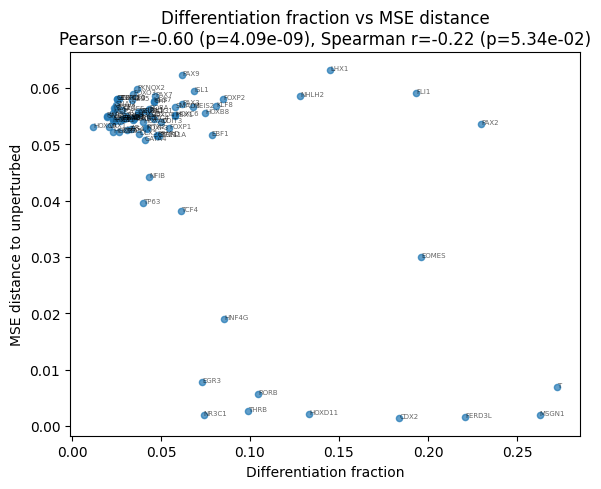

In [13]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Compute differentiation fraction per intervention (excluding unperturbed)
diff_frac = (
    adata.obs[adata.obs['intervention'] != 'unperturbed']
    .groupby('intervention')['is_differentiated']
    .mean()
    .rename('diff_fraction')
)

# Merge with distance_df (exclude unperturbed row)
corr_df = (
    distance_df[distance_df['intervention'] != 'unperturbed']
    .set_index('intervention')
    .join(diff_frac)
    .dropna()
    .reset_index()
)

# Pearson and Spearman correlations
r_pearson, p_pearson = pearsonr(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'])
r_spearman, p_spearman = spearmanr(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'])

print(f"Pearson  r = {r_pearson:.3f},  p = {p_pearson:.3e}")
print(f"Spearman r = {r_spearman:.3f},  p = {p_spearman:.3e}")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df['diff_fraction'], corr_df['mse_distance_to_unperturbed'], s=20, alpha=0.7)
for _, row in corr_df.iterrows():
    ax.annotate(row['intervention'], (row['diff_fraction'], row['mse_distance_to_unperturbed']),
                fontsize=5, alpha=0.6)
ax.set_xlabel('Differentiation fraction')
ax.set_ylabel('MSE distance to unperturbed')
ax.set_title(f'Differentiation fraction vs MSE distance\n'
             f'Pearson r={r_pearson:.2f} (p={p_pearson:.2e}), '
             f'Spearman r={r_spearman:.2f} (p={p_spearman:.2e})')
plt.tight_layout()
plt.show()

### Visualization

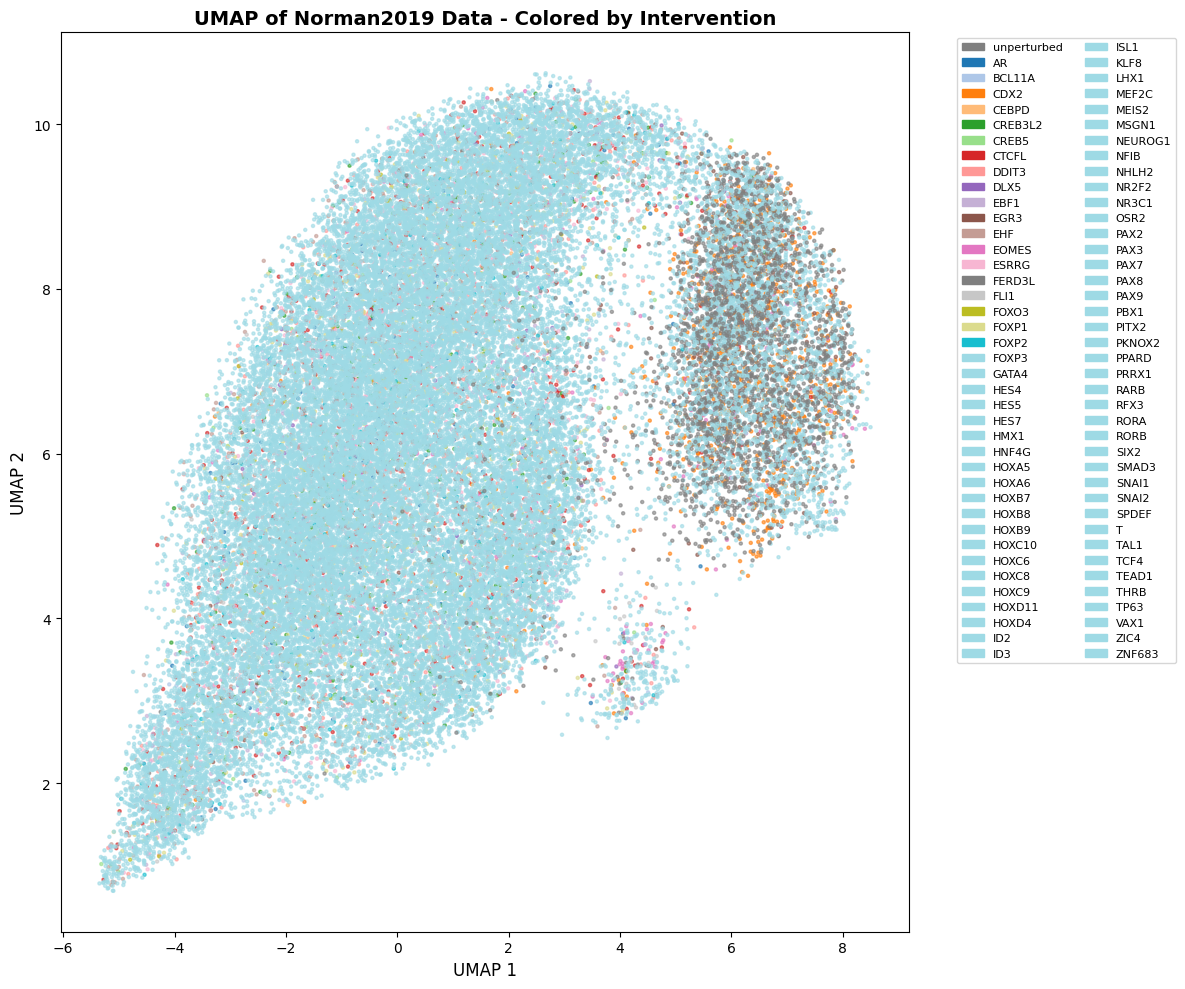

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Compute PCA (required for UMAP)
sc.tl.pca(adata)

# Compute UMAP
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Create color mapping: unperturbed in grey, others in distinct colors
interventions = adata.obs['intervention'].unique()
n_interventions = len(interventions)

# Generate color palette
color_palette = plt.cm.tab20(range(n_interventions))

# Create color map dictionary
intervention_colors = {}
for i, intervention in enumerate(sorted(interventions)):
    if intervention == 'unperturbed':
        intervention_colors[intervention] = '#808080'  # grey
    else:
        intervention_colors[intervention] = color_palette[i]

# Map colors to cells
cell_colors = [intervention_colors[intervention] for intervention in adata.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata.obsm['X_umap'][:, 0],
    adata.obsm['X_umap'][:, 1],
    c=cell_colors,
    s=5,
    alpha=0.6
)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Norman2019 Data - Colored by Intervention', fontsize=14, fontweight='bold')

# Create legend (only show subset to avoid overcrowding)
legend_elements = []
for intervention in sorted(interventions):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

# Add legend with smaller font and multiple columns
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

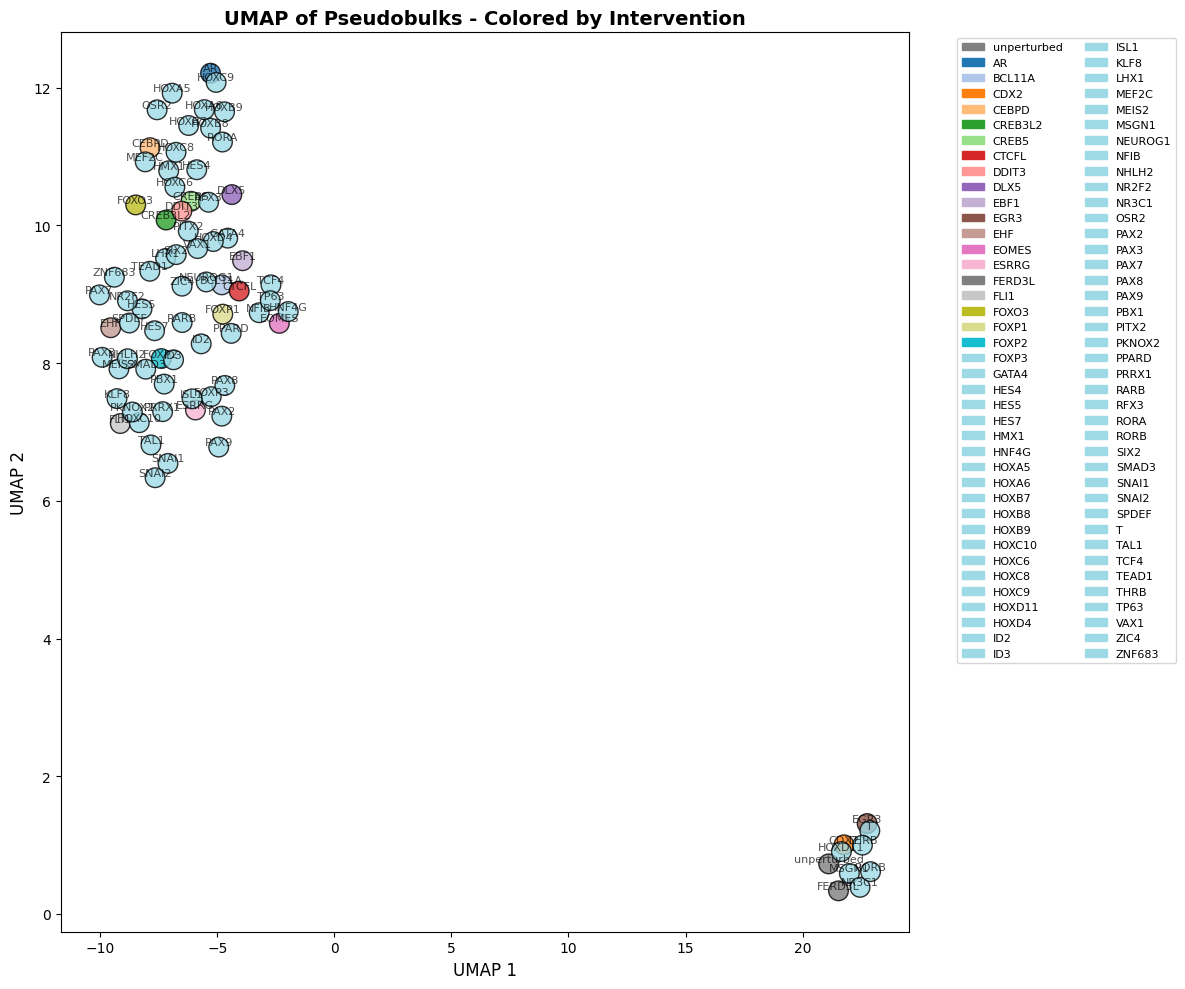

In [15]:
# Compute PCA for pseudobulks
sc.tl.pca(adata_pseudobulk)

# Compute UMAP for pseudobulks
sc.pp.neighbors(adata_pseudobulk, n_neighbors=5, n_pcs=20)
sc.tl.umap(adata_pseudobulk)

# Use same color scheme as before
pseudobulk_colors = [intervention_colors[intervention] for intervention in adata_pseudobulk.obs['intervention']]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP
scatter = ax.scatter(
    adata_pseudobulk.obsm['X_umap'][:, 0],
    adata_pseudobulk.obsm['X_umap'][:, 1],
    c=pseudobulk_colors,
    s=200,
    alpha=0.8,
    edgecolors='black',
    linewidth=1
)

# Add labels for each point
for i, intervention in enumerate(adata_pseudobulk.obs['intervention']):
    ax.annotate(
        intervention,
        (adata_pseudobulk.obsm['X_umap'][i, 0], adata_pseudobulk.obsm['X_umap'][i, 1]),
        fontsize=8,
        ha='center',
        va='bottom',
        alpha=0.7
    )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP of Pseudobulks - Colored by Intervention', fontsize=14, fontweight='bold')

# Add legend
legend_elements = []
for intervention in sorted(adata_pseudobulk.obs['intervention'].unique()):
    if intervention == 'unperturbed':
        legend_elements.insert(0, mpatches.Patch(color=intervention_colors[intervention], label=intervention))
    else:
        legend_elements.append(mpatches.Patch(color=intervention_colors[intervention], label=intervention))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
          fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

### Saving

In [16]:
# saving to output file
adata.write_h5ad(processed_data_file)
print(f'Saved processed data → {processed_data_file}')

Saved processed data → ../../../data/real/Joung2023/Joung2023_processed_50pct_gamma0p8.h5ad
